# Baseline 5 (Proposed): MS-ProtoNet with ResNet50 (MS-ProtoNet-50)

This notebook implements the **proposed Multi-Scale Prototypical Network** using **ResNet50** as the backbone.

### Key Contributions
- Multi-scale feature extraction from **layer2, layer3, layer4** of ResNet50
- Projection of heterogeneous features to a common embedding space
- Prototypical Network for few-shot classification
- **Feature caching** to reduce redundant computation during episodic training

Few-shot settings evaluated:
- 1-shot
- 5-shot
- 10-shot

## 1. Imports

In [1]:
import os, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Image Transform

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 3. ResNet50 Multi-Scale Feature Extractor

We explicitly extract features from:
- **layer2** → low/mid-level (512 channels)
- **layer3** → mid/high-level (1024 channels)
- **layer4** → high-level semantic features (2048 channels)

All features are projected to a **128-D space** before fusion.

In [3]:
class ResNet50MultiScale(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(pretrained=True)

        # Backbone blocks
        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2  # 512 ch
        self.layer3 = base.layer3  # 1024 ch
        self.layer4 = base.layer4  # 2048 ch

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Projection layers
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(1024, 128)
        self.fc4 = nn.Linear(2048, 128)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual blocks
        x = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)

        # Pooling
        v2 = self.gap(f2).view(f2.size(0), -1)
        v3 = self.gap(f3).view(f3.size(0), -1)
        v4 = self.gap(f4).view(f4.size(0), -1)

        # Projection
        z2 = self.fc2(v2)
        z3 = self.fc3(v3)
        z4 = self.fc4(v4)

        # Multi-scale fusion (concatenation)
        embedding = torch.cat([z2, z3, z4], dim=1)  # 384-D

        return embedding

## 4. Feature Cache

In [4]:
class FeatureCache:
    def __init__(self):
        self.cache = {}

    def get(self, key):
        return self.cache.get(key, None)

    def set(self, key, value):
        self.cache[key] = value

## 5. Few-Shot Dataset with Cached Features

Each image is passed through the ResNet50 backbone **once**, and the resulting multi-scale embedding is reused across episodes.

In [5]:
class FewShotDataset:
    def __init__(self, root, transform):
        self.root = root
        self.transform = transform

        self.classes = sorted(os.listdir(root))
        self.images = {
            c: [os.path.join(root, c, i) for i in os.listdir(os.path.join(root, c))]
            for c in self.classes
        }
    def sample_episode(self, n_way, k_shot, q_query):
        s_imgs, q_imgs, s_y, q_y = [], [], [], []
        classes = random.sample(self.classes, n_way)

        for label, cls in enumerate(classes):
            images = self.images[cls]

            # 🔒 Handle insufficient images by reuse
            if len(images) < (k_shot + q_query):
                print(
                    f"⚠️ Not enough images in class '{cls}'. "
                    f"Required={k_shot + q_query}, Available={len(images)}. Reusing images."
                )
                images = (
                    images * ((k_shot + q_query) // len(images) + 1)
                )[: k_shot + q_query]

            sampled_images = random.sample(images, k_shot + q_query)

            # Support set
            for img_path in sampled_images[:k_shot]:
                img = Image.open(img_path).convert("RGB")
                s_imgs.append(self.transform(img))
                s_y.append(label)

            # Query set
            for img_path in sampled_images[k_shot:]:
                img = Image.open(img_path).convert("RGB")
                q_imgs.append(self.transform(img))
                q_y.append(label)

        return (
            torch.stack(s_imgs),
            torch.tensor(s_y),
            torch.stack(q_imgs),
            torch.tensor(q_y),
        )



## 6. Prototypical Network Head

In [6]:
class ProtoNetHead(nn.Module):
    def forward(self, support_emb, support_y, query_emb):
        prototypes = []
        for c in torch.unique(support_y):
            prototypes.append(support_emb[support_y == c].mean(dim=0))
        prototypes = torch.stack(prototypes)

        distances = torch.cdist(query_emb, prototypes)
        return -distances

## 7. Training & Evaluation

In [7]:
def train_and_evaluate(k_shot, episodes_train=100, episodes_eval=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    encoder = ResNet50MultiScale().to(device)
    head = ProtoNetHead().to(device)

    # IMPORTANT: optimize BOTH encoder and head
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(head.parameters()),
        lr=1e-4
    )

    # Dataset returns IMAGES (not embeddings)
    train_data = FewShotDataset("clean_dataset/train", transform)
    val_data   = FewShotDataset("clean_dataset/val", transform)

    # =========================
    # TRAINING
    # =========================
    encoder.train()
    head.train()

    for ep in range(episodes_train):
        # ---- sample episode (IMAGES) ----
        print(f"Training episode {ep + 1}/100...")
        s_x, s_y, q_x, q_y = train_data.sample_episode(
            n_way=4, k_shot=k_shot, q_query=10
        )

        s_x, s_y = s_x.to(device), s_y.to(device)
        q_x, q_y = q_x.to(device), q_y.to(device)

        # ---- forward pass THROUGH encoder (CRITICAL) ----
        s_emb = encoder(s_x)
        q_emb = encoder(q_x)

        scores = head(s_emb, s_y, q_emb)
        loss = F.cross_entropy(scores, q_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # =========================
    # EVALUATION
    # =========================
    encoder.eval()
    head.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for eval_episode in range(episodes_eval):
            print(f"Evaluating episode {eval_episode + 1}/50...")
            s_x, s_y, q_x, q_y = val_data.sample_episode(
                n_way=4, k_shot=k_shot, q_query=10
            )

            s_x, s_y = s_x.to(device), s_y.to(device)
            q_x, q_y = q_x.to(device), q_y.to(device)

            s_emb = encoder(s_x)
            q_emb = encoder(q_x)

            preds = head(s_emb, s_y, q_emb).argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(q_y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm


## 8. Run 1-shot Experiments

RUNNING 1-SHOT EXPERIMENTS
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Sourodip/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100.0%


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

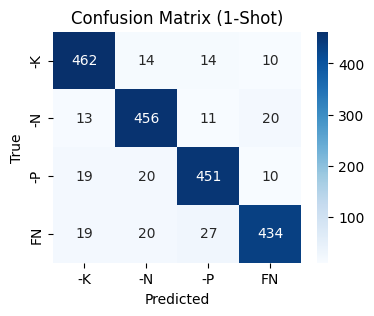

In [8]:
print("=" * 50)
print("RUNNING 1-SHOT EXPERIMENTS")
print("=" * 50)
acc, cm = train_and_evaluate(1)
print(f"\nMS-ProtoNet-50 | {1}-Shot Accuracy: {acc:.4f}")

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["-K", "-N", "-P", "FN"],
            yticklabels=["-K", "-N", "-P", "FN"])
plt.title(f"Confusion Matrix ({1}-Shot)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 9. Run 5-shot Experiments

RUNNING 5-SHOT EXPERIMENTS


c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

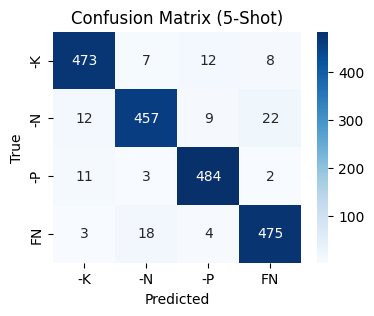

In [9]:
print("=" * 50)
print("RUNNING 5-SHOT EXPERIMENTS")
print("=" * 50)
acc, cm = train_and_evaluate(5)
print(f"\nMS-ProtoNet-50 | {5}-Shot Accuracy: {acc:.4f}")

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["-K", "-N", "-P", "FN"],
            yticklabels=["-K", "-N", "-P", "FN"])
plt.title(f"Confusion Matrix ({5}-Shot)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 10. Run 10-shot Experiments

RUNNING 10-SHOT EXPERIMENTS


c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Sourodip\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training episode 1/100...
Training episode 2/100...
Training episode 3/100...
Training episode 4/100...
Training episode 5/100...
Training episode 6/100...
Training episode 7/100...
Training episode 8/100...
Training episode 9/100...
Training episode 10/100...
Training episode 11/100...
Training episode 12/100...
Training episode 13/100...
Training episode 14/100...
Training episode 15/100...
Training episode 16/100...
Training episode 17/100...
Training episode 18/100...
Training episode 19/100...
Training episode 20/100...
Training episode 21/100...
Training episode 22/100...
Training episode 23/100...
Training episode 24/100...
Training episode 25/100...
Training episode 26/100...
Training episode 27/100...
Training episode 28/100...
Training episode 29/100...
Training episode 30/100...
Training episode 31/100...
Training episode 32/100...
Training episode 33/100...
Training episode 34/100...
Training episode 35/100...
Training episode 36/100...
Training episode 37/100...
Training e

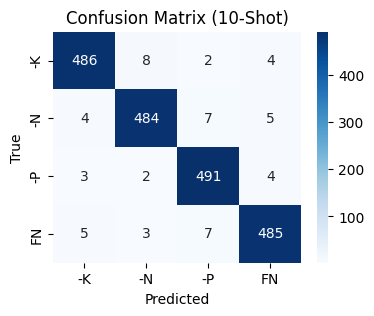

In [10]:
print("=" * 50)
print("RUNNING 10-SHOT EXPERIMENTS")
print("=" * 50)
acc, cm = train_and_evaluate(10)
print(f"\nMS-ProtoNet-50 | {10}-Shot Accuracy: {acc:.4f}")

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["-K", "-N", "-P", "FN"],
            yticklabels=["-K", "-N", "-P", "FN"])
plt.title(f"Confusion Matrix ({10}-Shot)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [1]:
import pandas as pd

data = {
    'Shots': [1, 5, 10],
    'Accuracy': [0.9015, 0.9445, 0.9730]
}

df = pd.DataFrame(data)

# Derive Percentage from Accuracy
df["Percentage"] = df["Accuracy"]

styled_df = (
    df.style
      .set_caption("Baseline 4: MS-ProtoNet-18")
      .format({
          "Accuracy": "{:.4f}",
          "Percentage": "{:.2%}"
      })
      .set_properties(**{"text-align": "center"})
)

styled_df


,Shots,Accuracy,Percentage
0,1,0.9015,90.15%
1,5,0.9445,94.45%
2,10,0.9730,97.30%
